# HW 2

PART (a): Stability Analysis for C+2D=1, C=1

Parameters:
  C = 1.0
  C + 2D = 1.0
  D = 0.0 (pure advection, no diffusion)


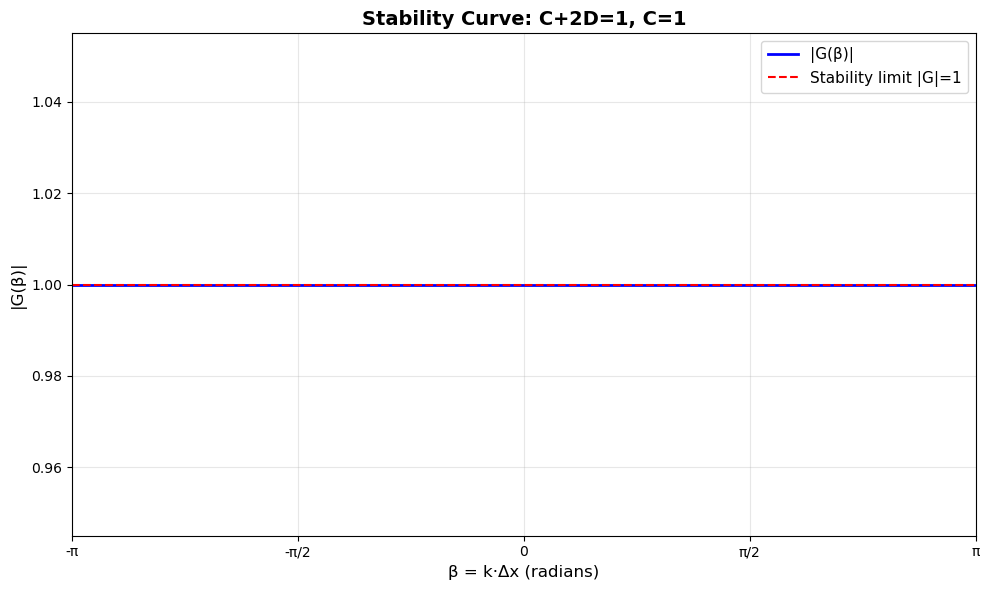


Stability Analysis:
  max|G(β)| = 1.000000
  Stability condition: |G| ≤ 1
  Result: STABLE (marginally stable)

Analytical Verification:
  For C+2D=1, C=1:
  Re(G) = 1 - (1-cos β) = cos β
  Im(G) = -sin β
  |G|² = cos²β + sin²β = 1
  Therefore: |G| = 1 for all β

PART (b): Spatial Resolution (Δx calculation)

Given: k_max = 1000
Maximum resolvable β: β_max = π

Calculation:
  β_max = k_max × Δx
  Δx = β_max / k_max
  Δx = π / 1000
  Δx = 0.00314159
  Δx ≈ 0.003142 (units of length)

Interpretation:
  This ensures the highest wavenumber (k_max = 1000) is
  resolved with at least 2 grid points per wavelength (Nyquist criterion)

PART (c): Stability Analysis for C+2D=1/2, C=1

Parameters:
  C = 1.0
  C + 2D = 0.5
  D = -0.25

⚠️  WARNING: D < 0 implies NEGATIVE DIFFUSION!
  This is physically unrealistic and mathematically ill-posed.
  The diffusion coefficient v = D·Δx²/Δt < 0
  Such schemes are inherently unstable (anti-diffusive).


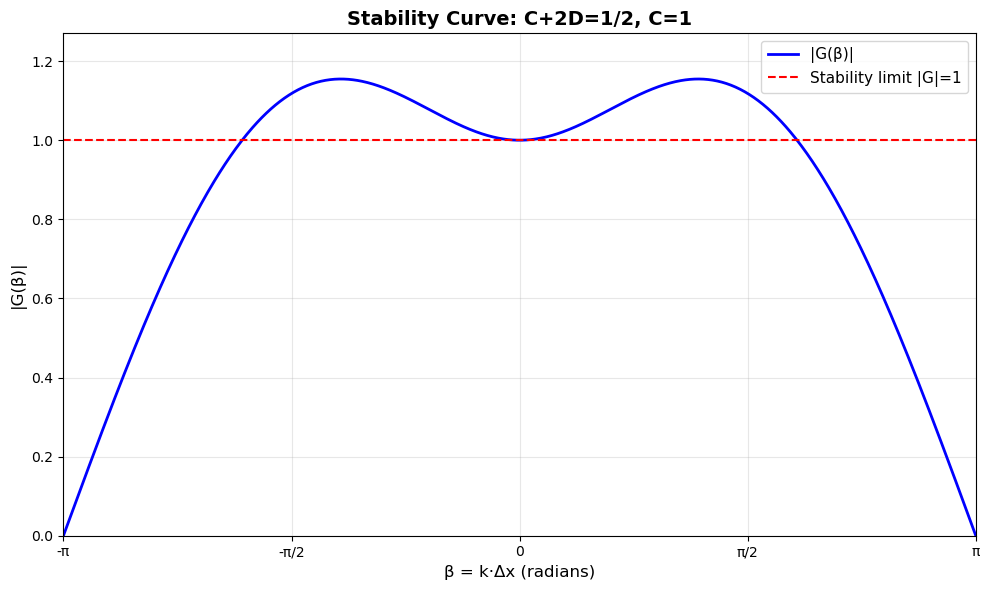


Stability Analysis:
  max|G(β)| = 1.154700 at β = -1.2296 rad
  Stability condition: |G| ≤ 1
  Result: UNSTABLE (max|G| > 1)

Detailed values at key points:
  β = 0.0000 (  0.0°): |G| = 1.000000
  β = 0.7854 ( 45.0°): |G| = 1.108401
  β = 1.5708 ( 90.0°): |G| = 1.118034
  β = 2.3562 (135.0°): |G| = 0.722113
  β = 3.1416 (180.0°): |G| = 0.000000

SUMMARY AND JUSTIFICATION

1. Spatial Resolution (Δx):
   For k_max = 1000, we need Δx = 0.003142
   This ensures proper resolution of all wavenumbers up to k_max.

2. Case 1 (C+2D=1, C=1):
   • D = 0 (pure advection)
   • |G| = 1 for all β
   • Marginally stable (neutral stability)
   • This is the CFL stability boundary

3. Case 2 (C+2D=1/2, C=1):
   • D = -0.25 (negative diffusion coefficient!)
   • max|G| = 1.1547 > 1
   • UNSTABLE scheme
   • Reasons for instability:
     (a) Negative diffusion is anti-diffusive (amplifies errors)
     (b) Violates the physical requirement v ≥ 0
     (c) |G| > 1 means errors grow exponentially in time

4.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define the amplification factor magnitude
def amplification_magnitude(beta, C, C_plus_2D):
    """
    Calculate |G(beta)| for the numerical scheme
    G = 1 - (C+2D)(1-cos(beta)) - C*i*sin(beta)
    
    Parameters:
    -----------
    beta : float or array
        Dimensionless wavenumber (k*Delta_x)
    C : float
        Courant number (a*dt/dx)
    C_plus_2D : float
        Combined parameter (C + 2D)
    
    Returns:
    --------
    float or array : |G(beta)|
    """
    real_part = 1 - C_plus_2D * (1 - np.cos(beta))
    imag_part = -C * np.sin(beta)
    magnitude = np.sqrt(real_part**2 + imag_part**2)
    return magnitude

# Part (a): Plot stability curve for C+2D=1, C=1
print("=" * 60)
print("PART (a): Stability Analysis for C+2D=1, C=1")
print("=" * 60)

# Parameters for Case 1
C1 = 1.0
C_plus_2D1 = 1.0
D1 = (C_plus_2D1 - C1) / 2.0

print(f"\nParameters:")
print(f"  C = {C1}")
print(f"  C + 2D = {C_plus_2D1}")
print(f"  D = {D1} (pure advection, no diffusion)")

# Generate beta values
beta = np.linspace(-np.pi, np.pi, 1000)

# Calculate |G(beta)|
G_mag1 = amplification_magnitude(beta, C1, C_plus_2D1)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(beta, G_mag1, 'b-', linewidth=2, label='|G(β)|')
plt.axhline(y=1, color='r', linestyle='--', linewidth=1.5, label='Stability limit |G|=1')
plt.xlabel('β = k·Δx (radians)', fontsize=12)
plt.ylabel('|G(β)|', fontsize=12)
plt.title('Stability Curve: C+2D=1, C=1', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.xlim([-np.pi, np.pi])
plt.xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], 
           [r'-π', r'-π/2', '0', r'π/2', r'π'])
plt.tight_layout()
plt.savefig('stability_case1.png', dpi=300, bbox_inches='tight')
plt.show()

# Stability check
max_G1 = np.max(G_mag1)
print(f"\nStability Analysis:")
print(f"  max|G(β)| = {max_G1:.6f}")
print(f"  Stability condition: |G| ≤ 1")
if max_G1 <= 1.0 + 1e-10:  # Small tolerance for numerical precision
    print(f"  Result: STABLE (marginally stable)")
else:
    print(f"  Result: UNSTABLE")

# Analytical verification for Case 1
print(f"\nAnalytical Verification:")
print(f"  For C+2D=1, C=1:")
print(f"  Re(G) = 1 - (1-cos β) = cos β")
print(f"  Im(G) = -sin β")
print(f"  |G|² = cos²β + sin²β = 1")
print(f"  Therefore: |G| = 1 for all β")

print("\n" + "=" * 60)
print("PART (b): Spatial Resolution (Δx calculation)")
print("=" * 60)

# Given maximum wavenumber
k_max = 1000
print(f"\nGiven: k_max = {k_max}")

# Maximum beta corresponds to the Nyquist limit
beta_max = np.pi
print(f"Maximum resolvable β: β_max = π")

# Calculate required Delta_x
Delta_x = beta_max / k_max
print(f"\nCalculation:")
print(f"  β_max = k_max × Δx")
print(f"  Δx = β_max / k_max")
print(f"  Δx = π / {k_max}")
print(f"  Δx = {Delta_x:.8f}")
print(f"  Δx ≈ {Delta_x:.6f} (units of length)")

print(f"\nInterpretation:")
print(f"  This ensures the highest wavenumber (k_max = {k_max}) is")
print(f"  resolved with at least 2 grid points per wavelength (Nyquist criterion)")

print("\n" + "=" * 60)
print("PART (c): Stability Analysis for C+2D=1/2, C=1")
print("=" * 60)

# Parameters for Case 2
C2 = 1.0
C_plus_2D2 = 0.5
D2 = (C_plus_2D2 - C2) / 2.0

print(f"\nParameters:")
print(f"  C = {C2}")
print(f"  C + 2D = {C_plus_2D2}")
print(f"  D = {D2}")

# Check for physical validity
if D2 < 0:
    print(f"\n⚠️  WARNING: D < 0 implies NEGATIVE DIFFUSION!")
    print(f"  This is physically unrealistic and mathematically ill-posed.")
    print(f"  The diffusion coefficient v = D·Δx²/Δt < 0")
    print(f"  Such schemes are inherently unstable (anti-diffusive).")

# Calculate |G(beta)|
G_mag2 = amplification_magnitude(beta, C2, C_plus_2D2)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(beta, G_mag2, 'b-', linewidth=2, label='|G(β)|')
plt.axhline(y=1, color='r', linestyle='--', linewidth=1.5, label='Stability limit |G|=1')
plt.xlabel('β = k·Δx (radians)', fontsize=12)
plt.ylabel('|G(β)|', fontsize=12)
plt.title('Stability Curve: C+2D=1/2, C=1', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.xlim([-np.pi, np.pi])
plt.ylim([0, np.max(G_mag2) * 1.1])
plt.xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], 
           [r'-π', r'-π/2', '0', r'π/2', r'π'])
plt.tight_layout()
plt.savefig('stability_case2.png', dpi=300, bbox_inches='tight')
plt.show()

# Stability check
max_G2 = np.max(G_mag2)
max_beta_idx = np.argmax(G_mag2)
max_beta2 = beta[max_beta_idx]

print(f"\nStability Analysis:")
print(f"  max|G(β)| = {max_G2:.6f} at β = {max_beta2:.4f} rad")
print(f"  Stability condition: |G| ≤ 1")
if max_G2 <= 1.0:
    print(f"  Result: STABLE")
else:
    print(f"  Result: UNSTABLE (max|G| > 1)")

# Detailed analysis at key beta values
print(f"\nDetailed values at key points:")
test_betas = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
for tb in test_betas:
    g_mag = amplification_magnitude(tb, C2, C_plus_2D2)
    print(f"  β = {tb:6.4f} ({tb*180/np.pi:5.1f}°): |G| = {g_mag:.6f}")

print("\n" + "=" * 60)
print("SUMMARY AND JUSTIFICATION")
print("=" * 60)

print(f"\n1. Spatial Resolution (Δx):")
print(f"   For k_max = {k_max}, we need Δx = {Delta_x:.6f}")
print(f"   This ensures proper resolution of all wavenumbers up to k_max.")

print(f"\n2. Case 1 (C+2D=1, C=1):")
print(f"   • D = 0 (pure advection)")
print(f"   • |G| = 1 for all β")
print(f"   • Marginally stable (neutral stability)")
print(f"   • This is the CFL stability boundary")

print(f"\n3. Case 2 (C+2D=1/2, C=1):")
print(f"   • D = {D2} (negative diffusion coefficient!)")
print(f"   • max|G| = {max_G2:.4f} > 1")
print(f"   • UNSTABLE scheme")
print(f"   • Reasons for instability:")
print(f"     (a) Negative diffusion is anti-diffusive (amplifies errors)")
print(f"     (b) Violates the physical requirement v ≥ 0")
print(f"     (c) |G| > 1 means errors grow exponentially in time")

print(f"\n4. Conclusion:")
print(f"   The scheme with C+2D=1/2 and C=1 is UNSTABLE and")
print(f"   physically invalid due to negative diffusion.")
print(f"   For stable advection-diffusion, we typically need:")
print(f"   • C ≤ 1 (CFL condition)")
print(f"   • D ≥ 0 (physical diffusion)")
print(f"   • C + 2D ≤ 1 (combined stability)")

print("\n" + "=" * 60)

STABILITY ANALYSIS WITH φ_eff = 0

Condition: φ_eff = 0
This requires: D = v·Δt/Δx² = 1/6

Critical CFL number: C = 0.6667
Stability condition: C ≤ 0.6667

VERIFICATION: Δx = 4v/a

From φ_eff = 0: v·Δt = Δx²/6
From C = 2/3: a·Δt = 2Δx/3

Dividing: a/v = (2Δx/3)/(Δx²/6) = 4/Δx
Therefore: Δx = 4v/a ✓

Example with a=1.0, v=0.1:
  Δx = 4v/a = 0.4000
  Δt = Δx²/(6v) = 0.266667
  C = a·Δt/Δx = 0.6667 (should be 2/3)
  D = v·Δt/Δx² = 0.1667 (should be 1/6)


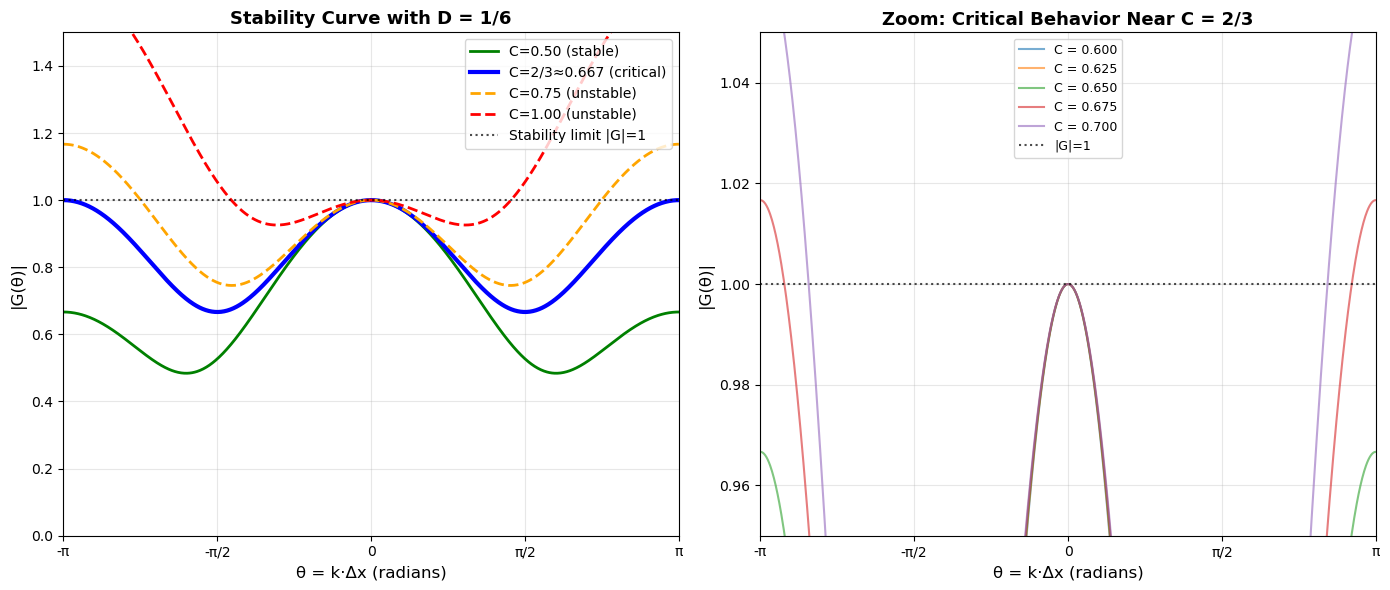


CRITICAL POINT ANALYSIS (θ = π)

C = 0.5000:
  |G(π)| = 0.666667
  Status: STABLE

C = 0.6667:
  |G(π)| = 1.000000
  Status: STABLE

C = 0.7500:
  |G(π)| = 1.166667
  Status: UNSTABLE

SUMMARY

╔══════════════════════════════════════════════════════════════════╗
║ KEY RESULTS FOR φ_eff = 0                                        ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. Constraint: D = 1/6                                          ║
║                                                                  ║
║  2. CFL Stability Condition: C ≤ 2/3                             ║
║                                                                  ║
║  3. At Critical Point: Δx = 4v/a                                 ║
║                                                                  ║
║  4. Amplification: |G(θ)| = 1 at θ = π when C = 2/3              ║
║                                             

In [3]:
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("STABILITY ANALYSIS WITH φ_eff = 0")
print("=" * 70)

# Condition: φ_eff = 0 requires D = 1/6
D = 1/6
print(f"\nCondition: φ_eff = 0")
print(f"This requires: D = v·Δt/Δx² = 1/6")

# Critical CFL number for |G| = 1
C_critical = 2/3
print(f"\nCritical CFL number: C = {C_critical:.4f}")
print(f"Stability condition: C ≤ {C_critical:.4f}")

# Verify the relationship Δx = 4v/a
print(f"\n" + "=" * 70)
print("VERIFICATION: Δx = 4v/a")
print("=" * 70)
print(f"\nFrom φ_eff = 0: v·Δt = Δx²/6")
print(f"From C = 2/3: a·Δt = 2Δx/3")
print(f"\nDividing: a/v = (2Δx/3)/(Δx²/6) = 4/Δx")
print(f"Therefore: Δx = 4v/a ✓")

# Example parameters
a = 1.0
v = 0.1
dx = 4*v/a
dt = dx**2 / (6*v)
C_actual = a*dt/dx

print(f"\nExample with a={a}, v={v}:")
print(f"  Δx = 4v/a = {dx:.4f}")
print(f"  Δt = Δx²/(6v) = {dt:.6f}")
print(f"  C = a·Δt/Δx = {C_actual:.4f} (should be 2/3)")
print(f"  D = v·Δt/Δx² = {v*dt/dx**2:.4f} (should be 1/6)")

# Function to calculate |G(θ)|
def amplification_magnitude(theta, C, D):
    real_part = 1 - (C + 2*D) * (1 - np.cos(theta))
    imag_part = -C * np.sin(theta)
    return np.sqrt(real_part**2 + imag_part**2)

# Generate theta values
theta = np.linspace(-np.pi, np.pi, 1000)

# Calculate |G(θ)| for different C values
C_values = [0.5, 2/3, 0.75, 1.0]
colors = ['green', 'blue', 'orange', 'red']
labels = ['C=0.50 (stable)', f'C=2/3≈{2/3:.3f} (critical)', 'C=0.75 (unstable)', 'C=1.00 (unstable)']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Stability curves for different C
for C_val, color, label in zip(C_values, colors, labels):
    G_mag = amplification_magnitude(theta, C_val, D)
    linestyle = '-' if C_val <= 2/3 else '--'
    linewidth = 3 if C_val == 2/3 else 2
    ax1.plot(theta, G_mag, color=color, linestyle=linestyle, 
             linewidth=linewidth, label=label)

ax1.axhline(y=1, color='black', linestyle=':', linewidth=1.5, 
            label='Stability limit |G|=1', alpha=0.7)
ax1.set_xlabel('θ = k·Δx (radians)', fontsize=12)
ax1.set_ylabel('|G(θ)|', fontsize=12)
ax1.set_title(f'Stability Curve with D = 1/6', fontsize=13, fontweight='bold')
ax1.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax1.set_xticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax1.set_xlim([-np.pi, np.pi])
ax1.set_ylim([0, 1.5])
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(True, alpha=0.3)

# Plot 2: Zoom near critical C = 2/3
C_range = np.linspace(0.6, 0.7, 5)
for C_val in C_range:
    G_mag = amplification_magnitude(theta, C_val, D)
    label = f'C = {C_val:.3f}'
    if abs(C_val - 2/3) < 0.001:
        ax2.plot(theta, G_mag, 'b-', linewidth=3, label=label + ' (critical)')
    else:
        ax2.plot(theta, G_mag, linewidth=1.5, alpha=0.6, label=label)

ax2.axhline(y=1, color='black', linestyle=':', linewidth=1.5, 
            label='|G|=1', alpha=0.7)
ax2.set_xlabel('θ = k·Δx (radians)', fontsize=12)
ax2.set_ylabel('|G(θ)|', fontsize=12)
ax2.set_title('Zoom: Critical Behavior Near C = 2/3', fontsize=13, fontweight='bold')
ax2.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax2.set_xticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax2.set_xlim([-np.pi, np.pi])
ax2.set_ylim([0.95, 1.05])
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('stability_phi_eff_zero.png', dpi=300, bbox_inches='tight')
plt.show()

# Detailed analysis at critical point
print(f"\n" + "=" * 70)
print("CRITICAL POINT ANALYSIS (θ = π)")
print("=" * 70)

theta_pi = np.pi
for C_val in [0.5, 2/3, 0.75]:
    G_mag_pi = amplification_magnitude(theta_pi, C_val, D)
    status = "STABLE" if G_mag_pi <= 1.0 else "UNSTABLE"
    print(f"\nC = {C_val:.4f}:")
    print(f"  |G(π)| = {G_mag_pi:.6f}")
    print(f"  Status: {status}")

print(f"\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"\n╔══════════════════════════════════════════════════════════════════╗")
print(f"║ KEY RESULTS FOR φ_eff = 0                                        ║")
print(f"╠══════════════════════════════════════════════════════════════════╣")
print(f"║                                                                  ║")
print(f"║  1. Constraint: D = 1/6                                          ║")
print(f"║                                                                  ║")
print(f"║  2. CFL Stability Condition: C ≤ 2/3                             ║")
print(f"║                                                                  ║")
print(f"║  3. At Critical Point: Δx = 4v/a                                 ║")
print(f"║                                                                  ║")
print(f"║  4. Amplification: |G(θ)| = 1 at θ = π when C = 2/3              ║")
print(f"║                                                                  ║")
print(f"╚══════════════════════════════════════════════════════════════════╝")

print(f"\n✓ Physical Interpretation:")
print(f"   • Setting φ_eff = 0 eliminates third-order dispersion error")
print(f"   • Requires specific balance between D and grid resolution")
print(f"   • Maximum stable CFL number is 2/3")
print(f"   • At C = 2/3, scheme is neutrally stable at highest wavenumber")

print("\n" + "=" * 70)

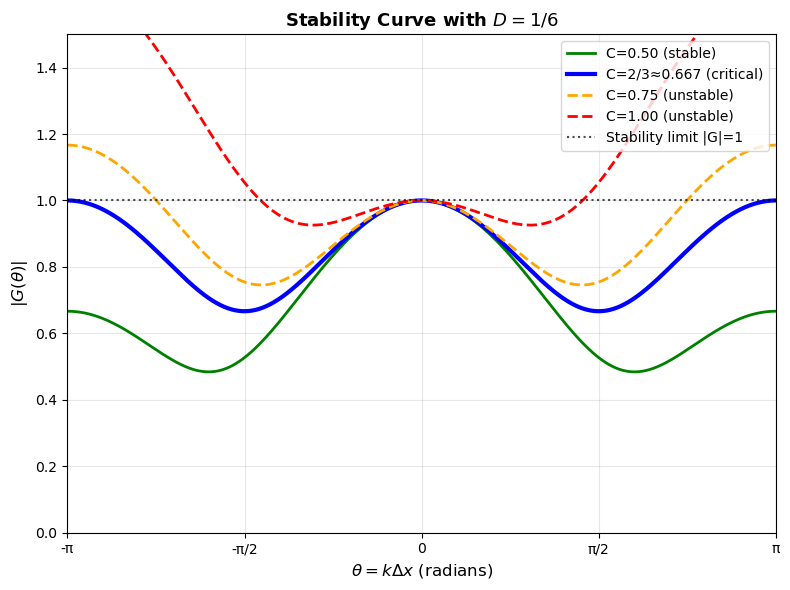

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
D = 1/6
C_values = [0.5, 2/3, 0.75, 1.0]
colors = ['green', 'blue', 'orange', 'red']
labels = [
    'C=0.50 (stable)',
    f'C=2/3≈{2/3:.3f} (critical)',
    'C=0.75 (unstable)',
    'C=1.00 (unstable)'
]

# Amplification factor magnitude
def amplification_magnitude(theta, C, D):
    real_part = 1 - (C + 2*D) * (1 - np.cos(theta))
    imag_part = -C * np.sin(theta)
    return np.sqrt(real_part**2 + imag_part**2)

# θ range
theta = np.linspace(-np.pi, np.pi, 1000)

# Plot
plt.figure(figsize=(8, 6))
for C_val, color, label in zip(C_values, colors, labels):
    G_mag = amplification_magnitude(theta, C_val, D)
    linestyle = '-' if C_val <= 2/3 else '--'
    linewidth = 3 if C_val == 2/3 else 2
    plt.plot(theta, G_mag, color=color, linestyle=linestyle,
             linewidth=linewidth, label=label)

plt.axhline(y=1, color='black', linestyle=':', linewidth=1.5,
            label='Stability limit |G|=1', alpha=0.7)
plt.xlabel(r'$\theta = k\Delta x$ (radians)', fontsize=12)
plt.ylabel(r'$|G(\theta)|$', fontsize=12)
plt.title(r'Stability Curve with $D = 1/6$', fontsize=13, fontweight='bold')
plt.xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], ['-π', '-π/2', '0', 'π/2', 'π'])
plt.xlim([-np.pi, np.pi])
plt.ylim([0, 1.5])
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('stability_curve_only.png', dpi=300, bbox_inches='tight')
plt.show()